In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Comparing Two Samples

Based on our findings can we conclude that smoking caused the difference in birthweight?

In [2]:
births = Table.read_table('baby.csv')

In [3]:
births.group('Maternal Smoker', np.average)

Maternal Smoker,Birth Weight average,Gestational Days average,Maternal Age average,Maternal Height average,Maternal Pregnancy Weight average
False,123.085,279.874,27.5441,64.014,129.48
True,113.819,277.898,26.7364,64.1046,126.919


What are other factors that could contribute to birthweight?

### Functions we will need for the next data set.
Comment in each fuction the answer to: What do these do?

In [4]:
def difference_of_means(table, numeric_label, group_label):
    """
    Takes: name of table, column label of numerical variable,
    column label of group-label variable
    
    Returns: Difference of means of the two groups
    """
    
    #table with the two relevant columns
    reduced = table.select(numeric_label, group_label)  
    
    # table containing group means
    means_table = reduced.group(group_label, np.average)
    
    # array of group means
    means = means_table.column(1)
    
    return means.item(1) - means.item(0)

In [5]:
def one_simulated_difference(table, numeric_label, group_label):
    """
    Takes: name of table, column label of numerical variable,
    column label of group-label variable
    
    Returns: Difference of means of the two groups after shuffling labels
    """
    
    # array of shuffled labels
    shuffled_labels = table.sample(
        with_replacement = False).column(group_label)
    
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(numeric_label).with_column(
        'Shuffled Label', shuffled_labels)
    
    return difference_of_means(
        shuffled_table, numeric_label, 'Shuffled Label')   

# Randomized Control Experiment

Establishing causality after a relationship (correlation) has been observerd, requires a randomized control experiment.
</br> Would it be ethical to run a study to establish if smoking was the cause of lower birthweight? Why or Why not?

### Botox Study
After years of hearing the botox helped relieve other pains, statisticians found a relationship and ran an experiement to determine if it was true. 

In [6]:
botox = Table.read_table('bta.csv')
botox.show()

Group,Result
Control,1
Control,1
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0


In [14]:
# Create a pivot table that shows the groups and how many had each result. 
# Do not assign it 

( botox
    .pivot('Result', 'Group')
    .relabel(1, 'No Improvement')
    .relabel(2, 'Improvement')
)

Group,No Improvement,Improvement
Control,14,2
Treatment,6,9


In [15]:
# Create a table that shows the average for each group.  
# Do not assign it 

botox.group('Group', np.average)

Group,Result average
Control,0.125
Treatment,0.6


**What are our hypotheses?**

* Null: ?
* Alternative: ?

**What statistic should we use to test our hypotheses?**

* Statistic: ?

**What values of our statistic will support the alternative hypothesis?**

* Statistic: ?

# Testing the Hypothesis

In [16]:
observed_diff = difference_of_means(botox, 'Result', 'Group')
observed_diff

0.475

In [17]:
one_simulated_difference(botox, 'Result', 'Group')


-0.041666666666666685

In [18]:
# Run 10,000 simulations. 

simulated_diffs = make_array()

for i in np.arange(10000):
    sim_diff = one_simulated_difference(botox, 'Result', 'Group')
    simulated_diffs = np.append(simulated_diffs, sim_diff)

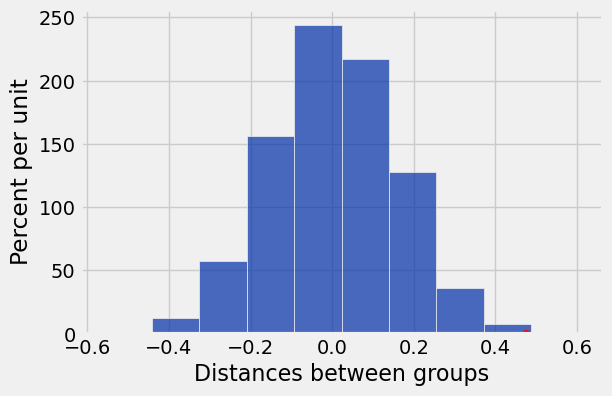

In [19]:
col_name = 'Distances between groups'

# Create a table with the given column name that stores the simulations.

distances = Table().with_column(col_name, simulated_diffs)

# Display a histogram with the default number of bins.

distances.hist(col_name)

# The following code plots the observed difference.
# It is difficult to see for some reason.
plots.scatter(observed_diff, 0, c = 'red')

In [20]:
# p-value
sum(simulated_diffs >= observed_diff) / len(simulated_diffs)

0.0091999999999999998

If our p-value cutoff was 1% would this data support the null or alternative hypothesis?

Can we say the botox causes reduction in pain? Why or Why not?